# Previous Violation History Figure


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from violmulti.data.dataset_loader import DatasetLoader
from violmulti.experiments.experiment import load_experiment
from violmulti.utils.violation_iti import *
from violmulti.visualizations.model_visualizer import *
from violmulti.models.linear_regression import *
import config as c

sns.set_context("talk")

%load_ext autoreload
%autoreload 2

DATA_PATH = "/Users/jessbreda/Desktop/github/violations-multinomial/data"

prev_viol_exp = "2025_04_09_fig2_fit_prev_violation_rs47.pkl"
filt_prev_viol_exp = "2025_04_09_fig2_fit_filt_prev_violation_rs47.pkl"
compare_exp = "2025_04_09_fig2_compare_prev_viol_rs47.pkl"

# A- Violation ITI & Hazard Rate


# B- Prev Viol Weights


In [8]:
mvpv = ModelVisualizer(load_experiment(prev_viol_exp))
XMIN=-2.1
XMAX=2.1

(-2.1, 2.1)

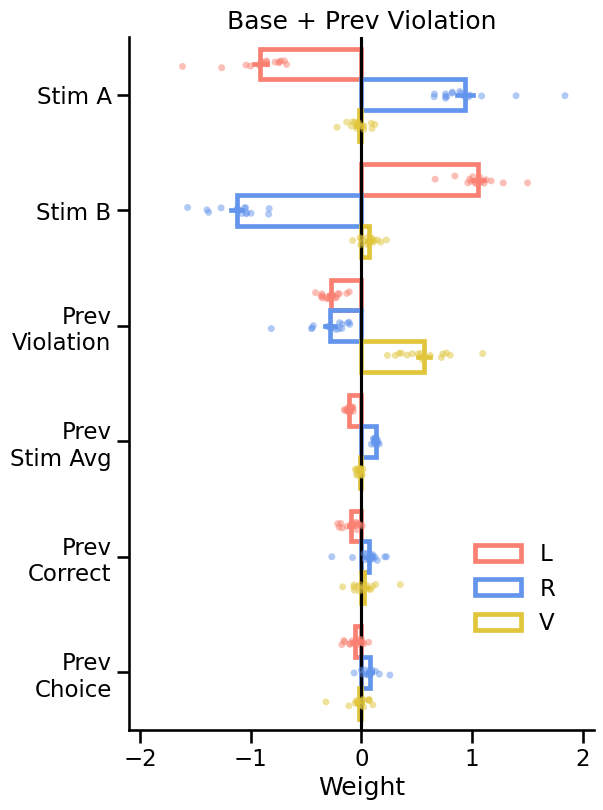

In [14]:
fig, ax = plt.subplots(figsize=(6, 9)) 

mvpv.plot_weights_summary(ax=ax,orientation="h", plot_bias = False, title="Base + Prev Violation", plot_individuals=True, seed=19, palette=c.MULTI_CHOICE_PAL)

ax.legend(bbox_to_anchor=(0.7, 0.3), frameon=False)

LABELS = [
    "Stim A", 
    "Stim B", 
    "Prev\nViolation", 
    "Prev\nStim Avg", 
    "Prev\nCorrect", 
    "Prev\nChoice"
]

# set y labels
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels(LABELS)

# set x label
ax.set_xlabel("Weight")
ax.set_xlim(XMIN, XMAX)


# C/D Filt Prev Viol Weights & Tau


In [4]:
mvfpv = ModelVisualizer(load_experiment(filt_prev_viol_exp))



(-2.1, 2.1)

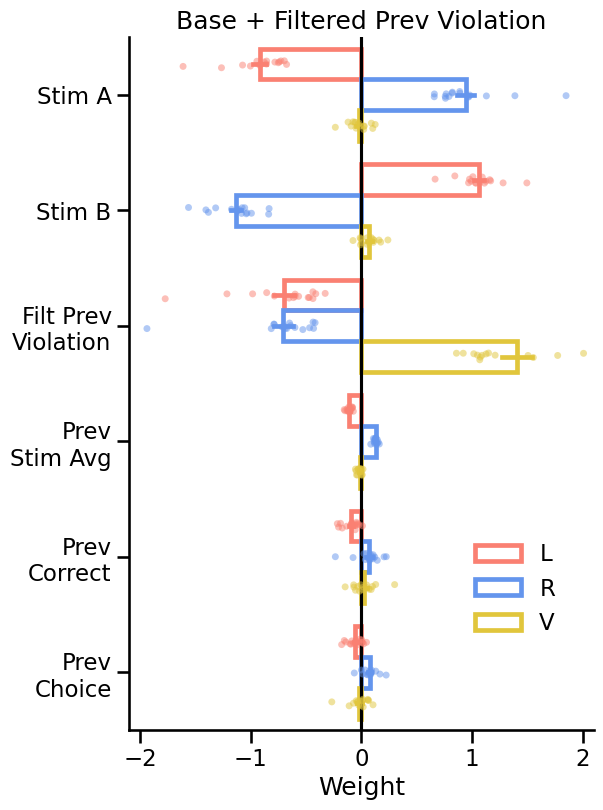

In [13]:
fig, ax = plt.subplots(figsize=(6, 9)) 

mvfpv.plot_weights_summary(ax=ax,orientation="h", plot_bias = False, title="Base + Filtered Prev Violation", plot_individuals=True, seed=19, palette=c.MULTI_CHOICE_PAL)

ax.legend(bbox_to_anchor=(0.7, 0.3), frameon=False)

LABELS = [
    "Stim A", 
    "Stim B", 
    "Filt Prev\nViolation", 
    "Prev\nStim Avg", 
    "Prev\nCorrect", 
    "Prev\nChoice"
]

# set y labels
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels(LABELS)

# set x label
ax.set_xlabel("Weight")
ax.set_xlim(XMIN, XMAX)



# E- Model Comparison


In [2]:
mvc = ModelVisualizerCompare(load_experiment(compare_exp))

ORDER = [
    "base",
    "prev_viol_binary",
    "prev_viol_filtered",
]
LABELS = [
    "Base\nMulti-class",
    "+ Binary \nPrev Violation",
    "+ Filtered \nPrev Violation",
]

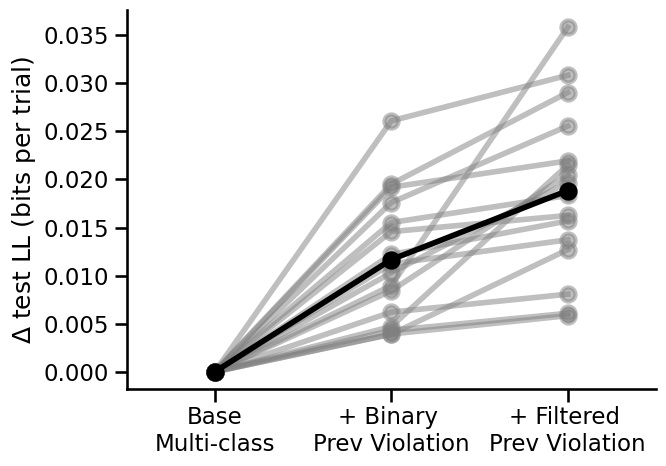

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.despine()
mvc.plot_model_comparison(
    hue="animal_id",
    ax=ax,
    order=ORDER,
    palette=["gray"] * 16,
    alpha = 0.5,
    y="bits_per_trial_relative_to_base"
)
mvc.plot_model_comparison(
    ax=ax,
    order=ORDER,
    color=c.MODEL_COMPARE_COLOR,
    errorbar=None,
    y="bits_per_trial_relative_to_base",
    ylabel="$\Delta$ test LL (bits per trial)",
)
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=0)
ax.legend().remove()
ax.set(xlabel="")

# save fig
plt.tight_layout()
# plt.savefig("figures/figX_compare_prev_viol.png", dpi=300, bbox_inches="tight")

## Base vs Binary


In [18]:
mvc.compute_overall_ll_ratio(base_model_name="base", new_model_name="prev_viol_binary")

/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:896: RuntimeWarning: overflow encountered in scalar power
  """
/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:900: RuntimeWarning: overflow encountered in scalar power
  params


{'overall_ratio': inf, 'log10_overall_ratio': 1297.9930496690224}

> Pooling across animals, the test data are $10^{1298}$ times more likely under the new model than under the base model.


In [19]:
mvc.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_binary")

{'geometric_mean_ratio': 1.332188266828118e+81,
 'log10_geometric_mean_ratio': 81.1245656043139}

> On average, each animal's test data is $1.33 * 10^{81}$ times more likely under the previous violation binary model


## Base vs Filtered


In [17]:
mvc.compute_overall_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered")

/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:896: RuntimeWarning: overflow encountered in scalar power
  """
/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:900: RuntimeWarning: overflow encountered in scalar power
  params


{'overall_ratio': inf, 'log10_overall_ratio': 2311.621968203722}

> Pooling across animals, the test data are $10^{2312}$ times more likely under the new model than under the base model.


In [20]:
mvc.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered")

{'geometric_mean_ratio': 2.994835777437509e+144,
 'log10_geometric_mean_ratio': 144.47637301273264}

> On average, each animal's test data is $3.0 * 10^{144}$ times more likely under the previous violation filtered model
